In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import pearsonr
from scipy.signal import find_peaks

In [23]:
df_blur = pd.read_csv("waveforms_blur8.csv")

In [24]:
df_blur.head()

,Frame,blur_sigma_0,blur_sigma_0.5,blur_sigma_0.7142857142857143,blur_sigma_0.9285714285714286,blur_sigma_1.1428571428571428,blur_sigma_1.3571428571428572,blur_sigma_1.5714285714285714,blur_sigma_1.7857142857142856,blur_sigma_2.0
0,0,-0.032163,0.023188,0.023018,0.015940,0.014437,0.015666,0.017746,0.008084,0.008996
1,1,-0.028863,0.019098,0.018513,0.012336,0.011010,0.012131,0.013808,0.006293,0.007085
2,2,-0.024528,0.012369,0.011140,0.007043,0.006058,0.007086,0.008193,0.003724,0.004345
3,3,-0.021402,0.004735,0.002869,0.002218,0.001746,0.002796,0.003419,0.001520,0.001995
4,4,-0.019976,-0.002569,-0.004850,-0.001121,-0.000885,0.000258,0.000584,0.000205,0.000584


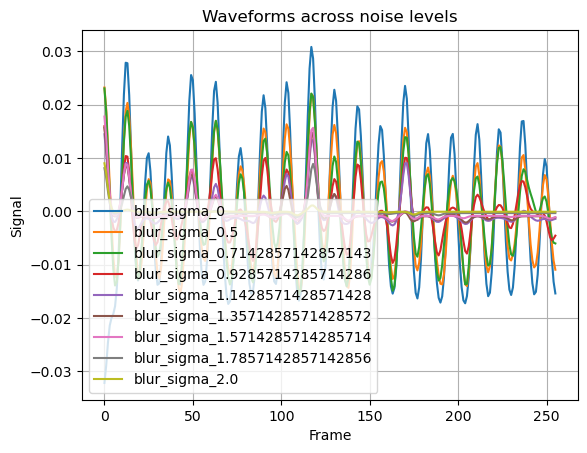

In [29]:
noise_levels = list(df_blur.columns)  # convert to list
noise_levels.remove("Frame")         # remove Frame column properly

for noise in noise_levels:
    x = df_blur["Frame"]
    y = df_blur[noise]
    plt.plot(x, y, label=noise)

plt.xlabel("Frame")
plt.ylabel("Signal")
plt.title("Waveforms across noise levels")
plt.legend()
plt.grid(True)
plt.show()

In [30]:
df_manual_rice = pd.read_csv("noise_manual_waveforms.csv")

<bound method NDFrame.head of      Frame     clean  sigma_0.1  sigma_0.125  sigma_0.25  sigma_0.375  \
0        1  0.091666   0.058163     0.059868    0.058613     0.069976   
1        2  0.086422   0.064999     0.065076    0.065072     0.072995   
2        3  0.092274   0.066280     0.067521    0.064536     0.068105   
3        4  0.094360   0.068300     0.063134    0.063134     0.067259   
4        5  0.095342   0.068124     0.064992    0.059343     0.072534   
..     ...       ...        ...          ...         ...          ...   
251    252  0.087279   0.073402     0.066010    0.052560     0.061634   
252    253  0.091537   0.080236     0.073681    0.059145     0.069038   
253    254  0.093781   0.075042     0.073670    0.054693     0.072534   
254    255  0.096331   0.076755     0.078926    0.073324     0.064105   
255    256  0.095723   0.075887     0.067027    0.061698     0.067349   

     sigma_0.5  sigma_0.625  sigma_0.75  sigma_0.875  
0     0.064259     0.062869    0.06026

In [88]:
df_manual_rice.columns
df_manual_rice = df_manual_rice.rename(columns={"sigma_0.1": "sigma_1.0"})

In [35]:

df_manual_rice = df_manual_rice[[c for c in df_manual_rice.columns if c != "sigma_1.0"] + ["sigma_1.0"]]
df_manual_rice.columns

Index(['Frame', 'clean', 'sigma_0.125', 'sigma_0.25', 'sigma_0.375',
       'sigma_0.5', 'sigma_0.625', 'sigma_0.75', 'sigma_0.875', 'sigma_1.0'],
      dtype='object')

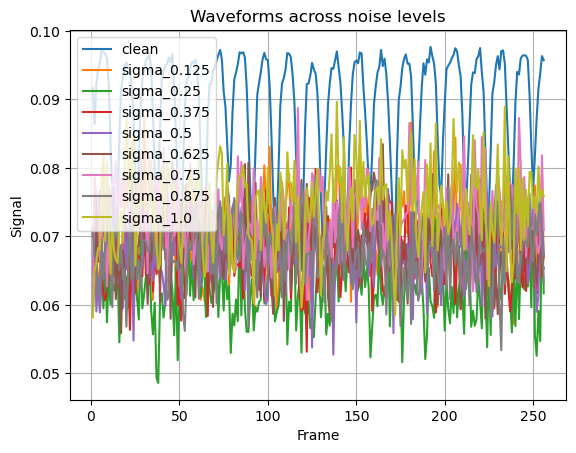

In [36]:
noise_levels = list(df_manual_rice.columns)  # convert to list
noise_levels.remove("Frame")         # remove Frame column properly

for noise in noise_levels:
    x = df_manual_rice["Frame"]
    y = df_manual_rice[noise]
    plt.plot(x, y, label=noise)

plt.xlabel("Frame")
plt.ylabel("Signal")
plt.title("Waveforms across noise levels")
plt.legend()
plt.grid(True)
plt.show()

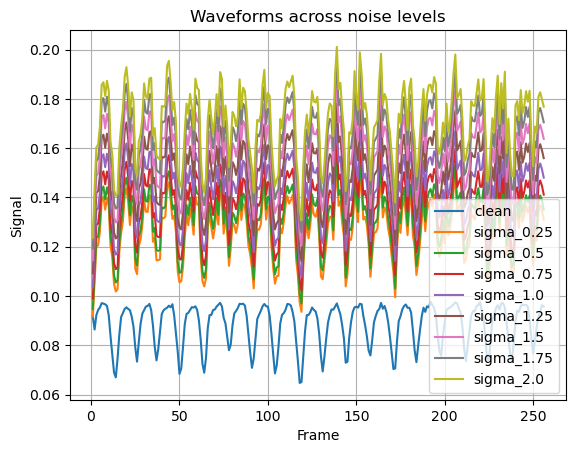

In [38]:
df_manual_blur = pd.read_csv("blur_manual_waveforms.csv")
noise_levels = list(df_manual_blur.columns)  # convert to list
noise_levels.remove("Frame")         # remove Frame column properly

for noise in noise_levels:
    x = df_manual_blur["Frame"]
    y = df_manual_blur[noise]
    plt.plot(x, y, label=noise)

plt.xlabel("Frame")
plt.ylabel("Signal")
plt.title("Waveforms across noise levels")
plt.legend()
plt.grid(True)
plt.show()

In [63]:
df_jac_rice = pd.read_csv("rice_jac_waveforms.csv")
df_jac_rice = df_jac_rice.rename(columns={"rice_sigma_0.1": "rice_sigma_1.0"})

df_jac_rice = df_jac_rice[[c for c in df_jac_rice.columns if c != "rice_sigma_1.0"] + ["rice_sigma_1.0"]]
df_jac_rice.columns

Index(['Frame', 'rice_sigma_0', 'rice_sigma_0.125', 'rice_sigma_0.25',
       'rice_sigma_0.375', 'rice_sigma_0.5', 'rice_sigma_0.625',
       'rice_sigma_0.75', 'rice_sigma_0.875', 'rice_sigma_1.0'],
      dtype='object')

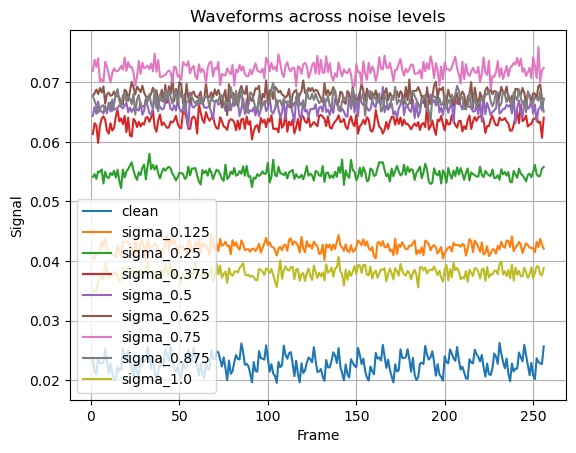

In [42]:
noise_levels = list(df_auto_rice.columns)  # convert to list
noise_levels.remove("Frame")         # remove Frame column properly

for noise in noise_levels:
    x = df_auto_rice["Frame"]
    y = df_auto_rice[noise]
    plt.plot(x, y, label=noise)

plt.xlabel("Frame")
plt.ylabel("Signal")
plt.title("Waveforms across noise levels")
plt.legend()
plt.grid(True)
plt.show()

In [87]:
df_auto_blur = pd.read_csv("blur_auto_waveforms.csv")
df_auto_blur.columns

Index(['Frame', 'clean', 'sigma_0.25', 'sigma_0.5', 'sigma_0.75', 'sigma_1.0',
       'sigma_1.25', 'sigma_1.5', 'sigma_1.75', 'sigma_2.0'],
      dtype='object')

In [64]:
df_manual_rice
df_manual_blur
df_auto_rice
df_auto_blur
df_jac_rice

Index(['Frame', 'rice_sigma_0', 'rice_sigma_0.125', 'rice_sigma_0.25',
       'rice_sigma_0.375', 'rice_sigma_0.5', 'rice_sigma_0.625',
       'rice_sigma_0.75', 'rice_sigma_0.875', 'rice_sigma_1.0'],
      dtype='object')

In [ ]:
df_manual_rice
df_auto_rice
df_jac_rice

In [25]:
ref = df_blur["blur_sigma_0"].values

noise_levels = []
pcc_values = []
rmse_values = []
peak_errors = []

for col in df_blur.columns:
    if col == "Frame" or col == "blur_sigma_0":
        continue

    noisy = df_blur[col].values

    # -----------------
    # Pearson Correlation
    # -----------------
    pcc, _ = pearsonr(ref, noisy)

    # -----------------
    # RMSE
    # -----------------
    rmse = np.sqrt(np.mean((ref - noisy)**2))

    # -----------------
    # Peak Timing Error
    # -----------------
    peaks_ref, _ = find_peaks(ref)
    peaks_noisy, _ = find_peaks(noisy)

    min_len = min(len(peaks_ref), len(peaks_noisy))

    if min_len > 0:
        peak_error = np.mean(np.abs(peaks_ref[:min_len] - peaks_noisy[:min_len]))
    else:
        peak_error = np.nan

    # -----------------
    # Store
    # -----------------
    noise_levels.append(col)
    pcc_values.append(pcc)
    rmse_values.append(rmse)
    peak_errors.append(peak_error)



noise_numeric = [float(n.split("_")[-1]) for n in noise_levels]

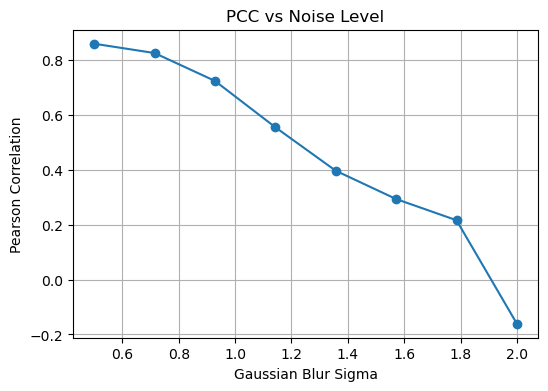

In [26]:
plt.figure(figsize=(6,4))
plt.plot(noise_numeric, pcc_values, marker='o')
plt.xlabel("Gaussian Blur Sigma")
plt.ylabel("Pearson Correlation")
plt.title("PCC vs Noise Level")
plt.grid(True)
plt.show()

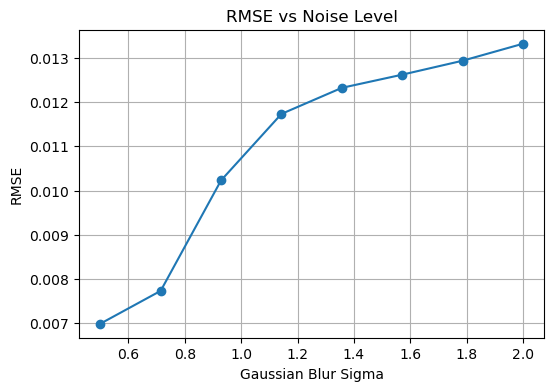

In [27]:
plt.figure(figsize=(6,4))
plt.plot(noise_numeric, rmse_values, marker='o')
plt.xlabel("Gaussian Blur Sigma")
plt.ylabel("RMSE")
plt.title("RMSE vs Noise Level")
plt.grid(True)
plt.show()

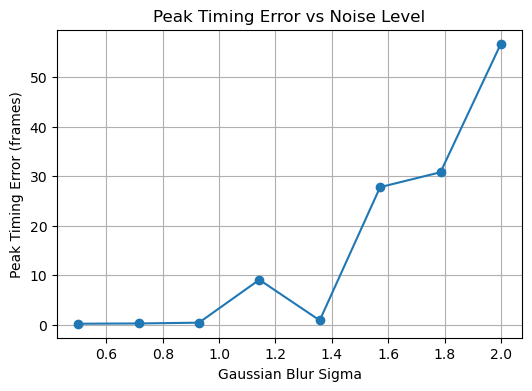

In [28]:
plt.figure(figsize=(6,4))
plt.plot(noise_numeric, peak_errors, marker='o')
plt.xlabel("Gaussian Blur Sigma")
plt.ylabel("Peak Timing Error (frames)")
plt.title("Peak Timing Error vs Noise Level")
plt.grid(True)
plt.show()

In [18]:
df_rice = pd.read_csv("waveforms_rice.csv")
df_rice.head()

,Frame,noisy_sigma_0,noisy_sigma_0.01,noisy_sigma_0.03,noisy_sigma_0.06,noisy_sigma_0.1
0,0,-0.032163,0.020168,0.024991,0.014022,0.016563
1,1,-0.028863,0.016859,0.020369,0.011619,0.013634
2,2,-0.024528,0.011310,0.012895,0.007617,0.009093
3,3,-0.021402,0.004819,0.004650,0.002874,0.004402
4,4,-0.019976,-0.001605,-0.002939,-0.002155,0.000295


In [19]:
ref = df_rice["noisy_sigma_0"].values

noise_levels = []
pcc_values = []
rmse_values = []
peak_errors = []

for col in df_blur.columns:
    if col == "Frame" or col == "noisy_sigma_0":
        continue

    noisy = df_blur[col].values

    # -----------------
    # Pearson Correlation
    # -----------------
    pcc, _ = pearsonr(ref, noisy)

    # -----------------
    # RMSE
    # -----------------
    rmse = np.sqrt(np.mean((ref - noisy)**2))

    # -----------------
    # Peak Timing Error
    # -----------------
    peaks_ref, _ = find_peaks(ref)
    peaks_noisy, _ = find_peaks(noisy)

    min_len = min(len(peaks_ref), len(peaks_noisy))

    if min_len > 0:
        peak_error = np.mean(np.abs(peaks_ref[:min_len] - peaks_noisy[:min_len]))
    else:
        peak_error = np.nan

    # -----------------
    # Store
    # -----------------
    noise_levels.append(col)
    pcc_values.append(pcc)
    rmse_values.append(rmse)
    peak_errors.append(peak_error)



noise_numeric = [float(n.split("_")[-1]) for n in noise_levels]

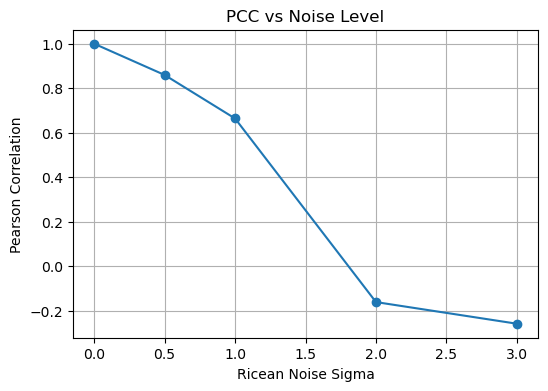

In [20]:
plt.figure(figsize=(6,4))
plt.plot(noise_numeric, pcc_values, marker='o')
plt.xlabel("Ricean Noise Sigma")
plt.ylabel("Pearson Correlation")
plt.title("PCC vs Noise Level")
plt.grid(True)
plt.show()

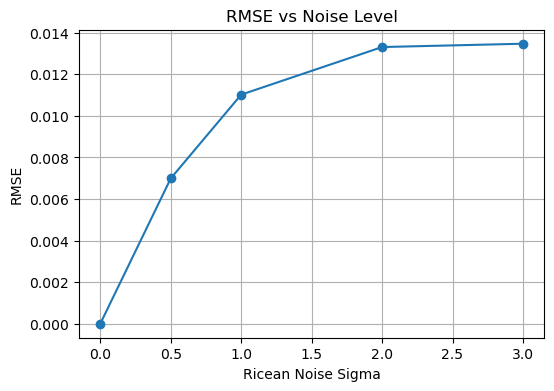

In [21]:
plt.figure(figsize=(6,4))
plt.plot(noise_numeric, rmse_values, marker='o')
plt.xlabel("Ricean Noise Sigma")
plt.ylabel("RMSE")
plt.title("RMSE vs Noise Level")
plt.grid(True)
plt.show()

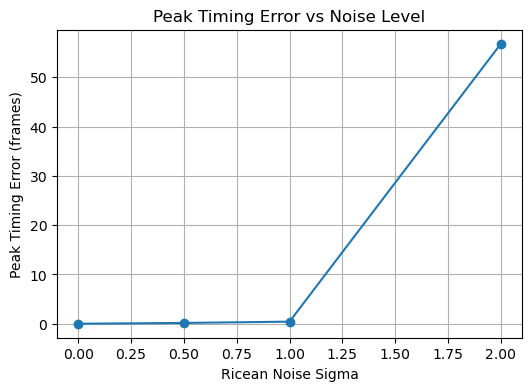

In [22]:
plt.figure(figsize=(6,4))
plt.plot(noise_numeric, peak_errors, marker='o')
plt.xlabel("Ricean Noise Sigma")
plt.ylabel("Peak Timing Error (frames)")
plt.title("Peak Timing Error vs Noise Level")
plt.grid(True)
plt.show()

In [72]:
df_jac_blur = pd.read_csv("blur_jac_waveforms.csv")
df_jac_blur.head()

,Frame,blur_sigma_0,blur_sigma_0.25,blur_sigma_0.5,blur_sigma_0.75,blur_sigma_1.0,blur_sigma_1.25,blur_sigma_1.5,blur_sigma_1.75,blur_sigma_2.0
0,0,-0.032163,0.025689,0.023188,0.021797,0.015194,0.014832,0.017041,0.020232,0.008996
1,1,-0.028863,0.021189,0.019098,0.017252,0.011598,0.011419,0.013254,0.015877,0.007085
2,2,-0.024528,0.013957,0.012369,0.009865,0.006369,0.006548,0.007854,0.009673,0.004345
3,3,-0.021402,0.006077,0.004735,0.001753,0.001735,0.002406,0.003263,0.004399,0.001995
4,4,-0.019976,-0.001097,-0.002569,-0.005449,-0.001212,-0.000040,0.000540,0.001257,0.000584


In [73]:
df_manual_blur.head()

,Frame,sigma_0,sigma_0.25,sigma_0.5,sigma_0.75,sigma_1.0,sigma_1.25,sigma_1.5,sigma_1.75,sigma_2.0
0,1,0.091666,0.091675,0.094719,0.099046,0.103806,0.109201,0.114591,0.119267,0.123676
1,2,0.086422,0.106169,0.109532,0.114450,0.120051,0.126454,0.132834,0.138347,0.143494
2,3,0.092274,0.120011,0.123620,0.128907,0.134968,0.141850,0.148764,0.154732,0.160310
3,4,0.094360,0.120601,0.124159,0.129438,0.135559,0.142596,0.149644,0.155764,0.161500
4,5,0.095342,0.126223,0.130078,0.135617,0.141866,0.149040,0.156275,0.162548,0.168438


In [74]:
df_auto_blur.head()

,Frame,sigma_0,sigma_0.25,sigma_0.5,sigma_0.75,sigma_1.0,sigma_1.25,sigma_1.5,sigma_1.75,sigma_2.0
0,1,0.023589,0.023597,0.025922,0.028977,0.031927,0.035015,0.038065,0.040892,0.043675
1,2,0.021431,0.026335,0.029054,0.032664,0.036212,0.039866,0.043443,0.046738,0.049988
2,3,0.021020,0.027346,0.030245,0.034041,0.037730,0.041603,0.045441,0.049002,0.052500
3,4,0.023663,0.030250,0.033161,0.037085,0.040969,0.045105,0.049247,0.053106,0.056893
4,5,0.022812,0.030208,0.033323,0.037468,0.041538,0.045821,0.050075,0.054050,0.057960


In [76]:
def compute_pcc(df, ref_col):

    ref = df[ref_col].values

    noise_levels = []
    pcc_values = []

    for col in df.columns:
        if col == "Frame" or col == ref_col:
            continue

        noisy = df[col].values

        pcc, _ = pearsonr(ref, noisy)

        noise_levels.append(col)
        pcc_values.append(pcc)

    noise_numeric = [float(n.split("_")[-1]) for n in noise_levels]

    return noise_numeric, pcc_values

In [75]:
noise_m, pcc_manual = compute_pcc(df_manual_blur, "sigma_0")
noise_a, pcc_auto   = compute_pcc(df_auto_blur,   "sigma_0")
noise_j, pcc_jac    = compute_pcc(df_jac_blur,    "blur_sigma_0")

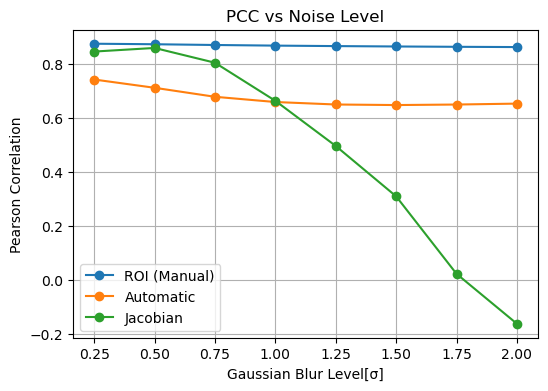

In [78]:
plt.figure(figsize=(6,4))

plt.plot(noise_m, pcc_manual, marker='o', label="ROI (Manual)")
plt.plot(noise_a, pcc_auto,   marker='o', label="Automatic")
plt.plot(noise_j, pcc_jac,    marker='o', label="Jacobian")

plt.xlabel("Gaussian Blur Level[σ]")
plt.ylabel("Pearson Correlation")
plt.title("PCC vs Noise Level")
plt.legend()
plt.grid(True)
plt.show()

In [79]:
from scipy.stats import pearsonr
from scipy.signal import find_peaks
import numpy as np

def compute_all_metrics(df, ref_col):

    ref = df[ref_col].values

    noise_levels = []
    pcc_values = []
    rmse_values = []
    peak_errors = []

    for col in df.columns:
        if col == "Frame" or col == ref_col:
            continue

        noisy = df[col].values

        # PCC
        pcc, _ = pearsonr(ref, noisy)

        # RMSE
        rmse = np.sqrt(np.mean((ref - noisy)**2))

        # Peak timing
        peaks_ref, _ = find_peaks(ref)
        peaks_noisy, _ = find_peaks(noisy)

        min_len = min(len(peaks_ref), len(peaks_noisy))

        peak_error = (
            np.mean(np.abs(peaks_ref[:min_len] - peaks_noisy[:min_len]))
            if min_len > 0 else np.nan
        )

        noise_levels.append(col)
        pcc_values.append(pcc)
        rmse_values.append(rmse)
        peak_errors.append(peak_error)

    noise_numeric = [float(n.split("_")[-1]) for n in noise_levels]

    return noise_numeric, pcc_values, rmse_values, peak_errors

In [81]:
noise_m, pcc_m, rmse_m, peak_m = compute_all_metrics(df_manual_blur, "sigma_0")
noise_a, pcc_a, rmse_a, peak_a = compute_all_metrics(df_auto_blur,   "sigma_0")
noise_j, pcc_j, rmse_j, peak_j = compute_all_metrics(df_jac_blur,    "blur_sigma_0")

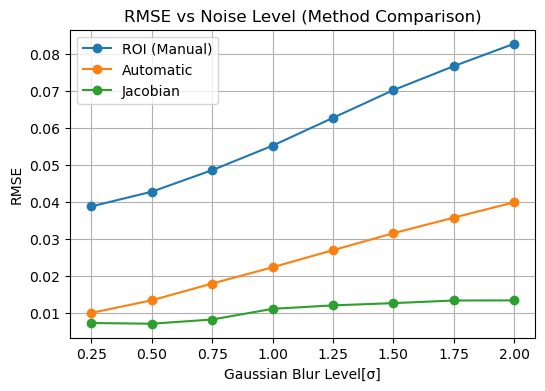

In [84]:
plt.figure(figsize=(6,4))

plt.plot(noise_m, rmse_m, marker='o', label="ROI (Manual)")
plt.plot(noise_a, rmse_a, marker='o', label="Automatic")
plt.plot(noise_j, rmse_j, marker='o', label="Jacobian")

plt.xlabel("Gaussian Blur Level[σ]")
plt.ylabel("RMSE")
plt.title("RMSE vs Noise Level (Method Comparison)")
plt.legend()
plt.grid(True)
plt.show()

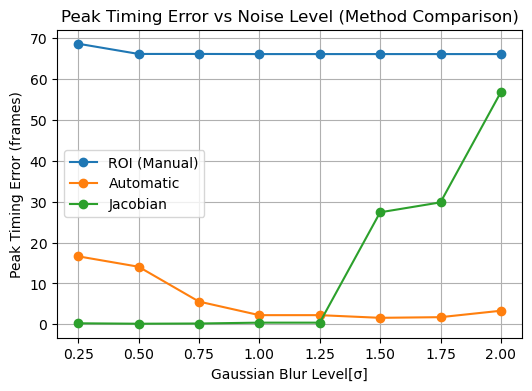

In [85]:
plt.figure(figsize=(6,4))

plt.plot(noise_m, peak_m, marker='o', label="ROI (Manual)")
plt.plot(noise_a, peak_a, marker='o', label="Automatic")
plt.plot(noise_j, peak_j, marker='o', label="Jacobian")

plt.xlabel("Gaussian Blur Level[σ]")
plt.ylabel("Peak Timing Error (frames)")
plt.title("Peak Timing Error vs Noise Level (Method Comparison)")
plt.legend()
plt.grid(True)
plt.show()

In [91]:
df_manual_rice = pd.read_csv("noise_manual_waveforms.csv")
df_manual_rice.head()
df_manual_rice = df_manual_rice.rename(columns={"clean": "sigma_0"})


In [92]:
df_manual_rice.head()

,Frame,sigma_0,sigma_0.025,sigma_0.05,sigma_0.075,sigma_0.1,sigma_0.125,sigma_0.15,sigma_0.175,sigma_0.2
0,1,0.091666,0.077568,0.063594,0.054058,0.055961,0.048297,0.048083,0.054617,0.053058
1,2,0.086422,0.090525,0.081659,0.065756,0.058422,0.053453,0.058880,0.061431,0.062285
2,3,0.092274,0.102149,0.087892,0.080610,0.064648,0.060179,0.066110,0.061466,0.066784
3,4,0.094360,0.100314,0.087073,0.071743,0.064771,0.072275,0.064645,0.058271,0.058749
4,5,0.095342,0.106129,0.093795,0.074860,0.069666,0.060688,0.061594,0.060863,0.060427


In [94]:
df_auto_rice = pd.read_csv("noise_auto_waveforms.csv")
df_auto_rice.head()
df_auto_rice = df_auto_rice.rename(columns={"clean": "sigma_0"})

In [95]:
df_auto_rice.head()

,Frame,sigma_0,sigma_0.025,sigma_0.05,sigma_0.075,sigma_0.1,sigma_0.125,sigma_0.15,sigma_0.175,sigma_0.2
0,1,0.023589,0.019549,0.023384,0.029024,0.033542,0.038922,0.044627,0.047173,0.048239
1,2,0.021431,0.022072,0.025522,0.029231,0.033972,0.037960,0.043978,0.047729,0.049178
2,3,0.021020,0.022960,0.025919,0.031795,0.034821,0.038481,0.046366,0.048389,0.049675
3,4,0.023663,0.025301,0.027734,0.032411,0.035096,0.039715,0.046142,0.048875,0.050368
4,5,0.022812,0.025100,0.027410,0.032089,0.035763,0.039563,0.045335,0.048948,0.049722


In [96]:
df_jac_rice = pd.read_csv("rice_jac_waveforms.csv")
df_jac_rice.head()

,Frame,rice_sigma_0,rice_sigma_0.025,rice_sigma_0.05,rice_sigma_0.075,rice_sigma_0.1,rice_sigma_0.125,rice_sigma_0.15,rice_sigma_0.175,rice_sigma_0.2
0,0,-0.032163,0.017929,0.013462,0.010786,0.014154,0.012375,0.009445,0.004374,0.012956
1,1,-0.028863,0.014760,0.011013,0.008431,0.011141,0.010166,0.008176,0.002820,0.010722
2,2,-0.024528,0.009451,0.006806,0.004409,0.006529,0.006724,0.006220,0.000046,0.007377
3,3,-0.021402,0.003225,0.001650,-0.000428,0.001951,0.003106,0.004288,-0.003198,0.004049
4,4,-0.019976,-0.002984,-0.003767,-0.005262,-0.001621,-0.000143,0.002821,-0.005764,0.001049


In [101]:
noise_m, pcc_m, rmse_m, peak_m = compute_all_metrics(df_manual_rice, "sigma_0")
noise_a, pcc_a, rmse_a, peak_a = compute_all_metrics(df_auto_rice,   "sigma_0")
noise_j, pcc_j, rmse_j, peak_j = compute_all_metrics(df_jac_rice,    "rice_sigma_0")

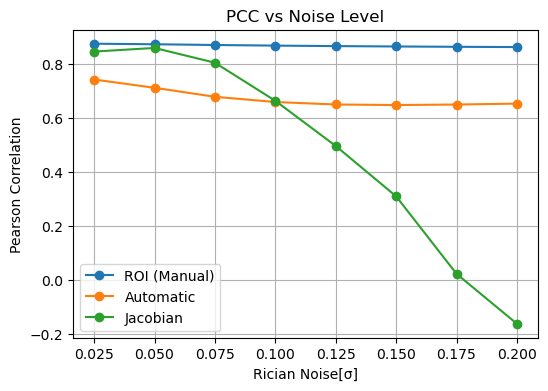

In [102]:
plt.figure(figsize=(6,4))

plt.plot(noise_m, pcc_manual, marker='o', label="ROI (Manual)")
plt.plot(noise_a, pcc_auto,   marker='o', label="Automatic")
plt.plot(noise_j, pcc_jac,    marker='o', label="Jacobian")

plt.xlabel("Rician Noise[σ]")
plt.ylabel("Pearson Correlation")
plt.title("PCC vs Noise Level")
plt.legend()
plt.grid(True)
plt.show()

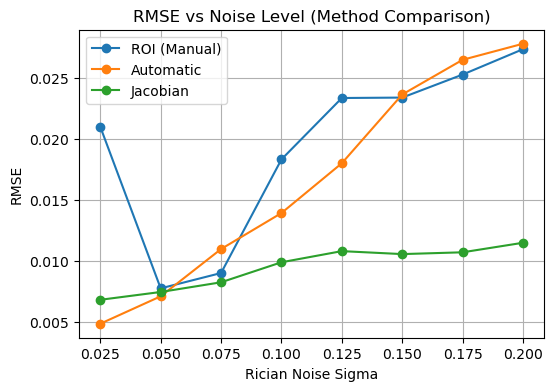

In [103]:
plt.figure(figsize=(6,4))

plt.plot(noise_m, rmse_m, marker='o', label="ROI (Manual)")
plt.plot(noise_a, rmse_a, marker='o', label="Automatic")
plt.plot(noise_j, rmse_j, marker='o', label="Jacobian")

plt.xlabel("Rician Noise Sigma")
plt.ylabel("RMSE")
plt.title("RMSE vs Noise Level (Method Comparison)")
plt.legend()
plt.grid(True)
plt.show()

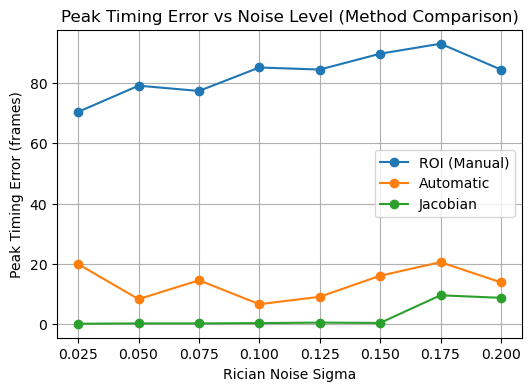

In [100]:
plt.figure(figsize=(6,4))

plt.plot(noise_m, peak_m, marker='o', label="ROI (Manual)")
plt.plot(noise_a, peak_a, marker='o', label="Automatic")
plt.plot(noise_j, peak_j, marker='o', label="Jacobian")

plt.xlabel("Rician Noise Sigma")
plt.ylabel("Peak Timing Error (frames)")
plt.title("Peak Timing Error vs Noise Level (Method Comparison)")
plt.legend()
plt.grid(True)
plt.show()